# 2D Latent Space Visualization (m=2 slice of sweep)

Retrain m=2 models with convergence detection, then visualize:
1. Feature trajectories z(t·eᵢ) — straight (linear) vs curved (nonlinear)
2. Decoder heatmaps — what each region of z-space reconstructs
3. Latent scatter — where data lands in z-space
4. Superposition tests — additivity violations

Grid: n∈{16,32,64,128} × l∈{1,2,3,4}, fixed S=0.9, m=2

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from core import Autoencoder, generate_sparse_data, device
from run_sweep_converged import train_to_convergence, max_steps_for_config
import os

S = 0.9
m = 2
n_values = [16, 32, 64, 128]
l_values = [1, 2, 3, 4]

print(f'Device: {device}')
print(f'Training {len(n_values) * len(l_values)} models with convergence detection...')

Device: cpu
Training 16 models with convergence detection...


In [2]:
# Load pre-trained m=2 models (trained separately to avoid notebook timeout)
from metrics import compute_nonlinear_gain

models = {}
model_info = {}

for n in n_values:
    for l in l_values:
        path = f'sweep_models/model_n{n}_m{m}_l{l}_S{S}.pt'
        model = Autoencoder(n, m, l, tied_weights=(l == 1)).to(device)
        model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
        model.eval()
        models[(n, l)] = model
        
        # Compute gain for display
        gain_info = compute_nonlinear_gain(model, S=S)
        model_info[(n, l)] = {
            'gain': gain_info['nonlinear_gain'],
            'mse_full': gain_info['mse_full'],
        }
        print(f'  n={n:3d}, l={l}: gain={gain_info["nonlinear_gain"]:.4f}')

print(f'\nLoaded {len(models)} models')

  n= 16, l=1: gain=0.0000
  n= 16, l=2: gain=0.3036
  n= 16, l=3: gain=0.3231
  n= 16, l=4: gain=0.4927
  n= 32, l=1: gain=0.0000
  n= 32, l=2: gain=0.1750
  n= 32, l=3: gain=0.2526
  n= 32, l=4: gain=0.3789
  n= 64, l=1: gain=0.0000
  n= 64, l=2: gain=0.0870
  n= 64, l=3: gain=0.2002
  n= 64, l=4: gain=0.2463
  n=128, l=1: gain=0.0000
  n=128, l=2: gain=0.0513
  n=128, l=3: gain=0.1541
  n=128, l=4: gain=0.1735

Loaded 16 models


## 1. Feature Trajectories

For each feature i, plot z(t·eᵢ) for t ∈ [0,1] in the 2D latent space.
- **l=1**: All trajectories are straight lines through origin (positive homogeneity)
- **l≥2**: Trajectories can curve — the curvature IS the nonlinear encoding

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_16076/2967703657.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(np.linspace(0, 1, n_features))


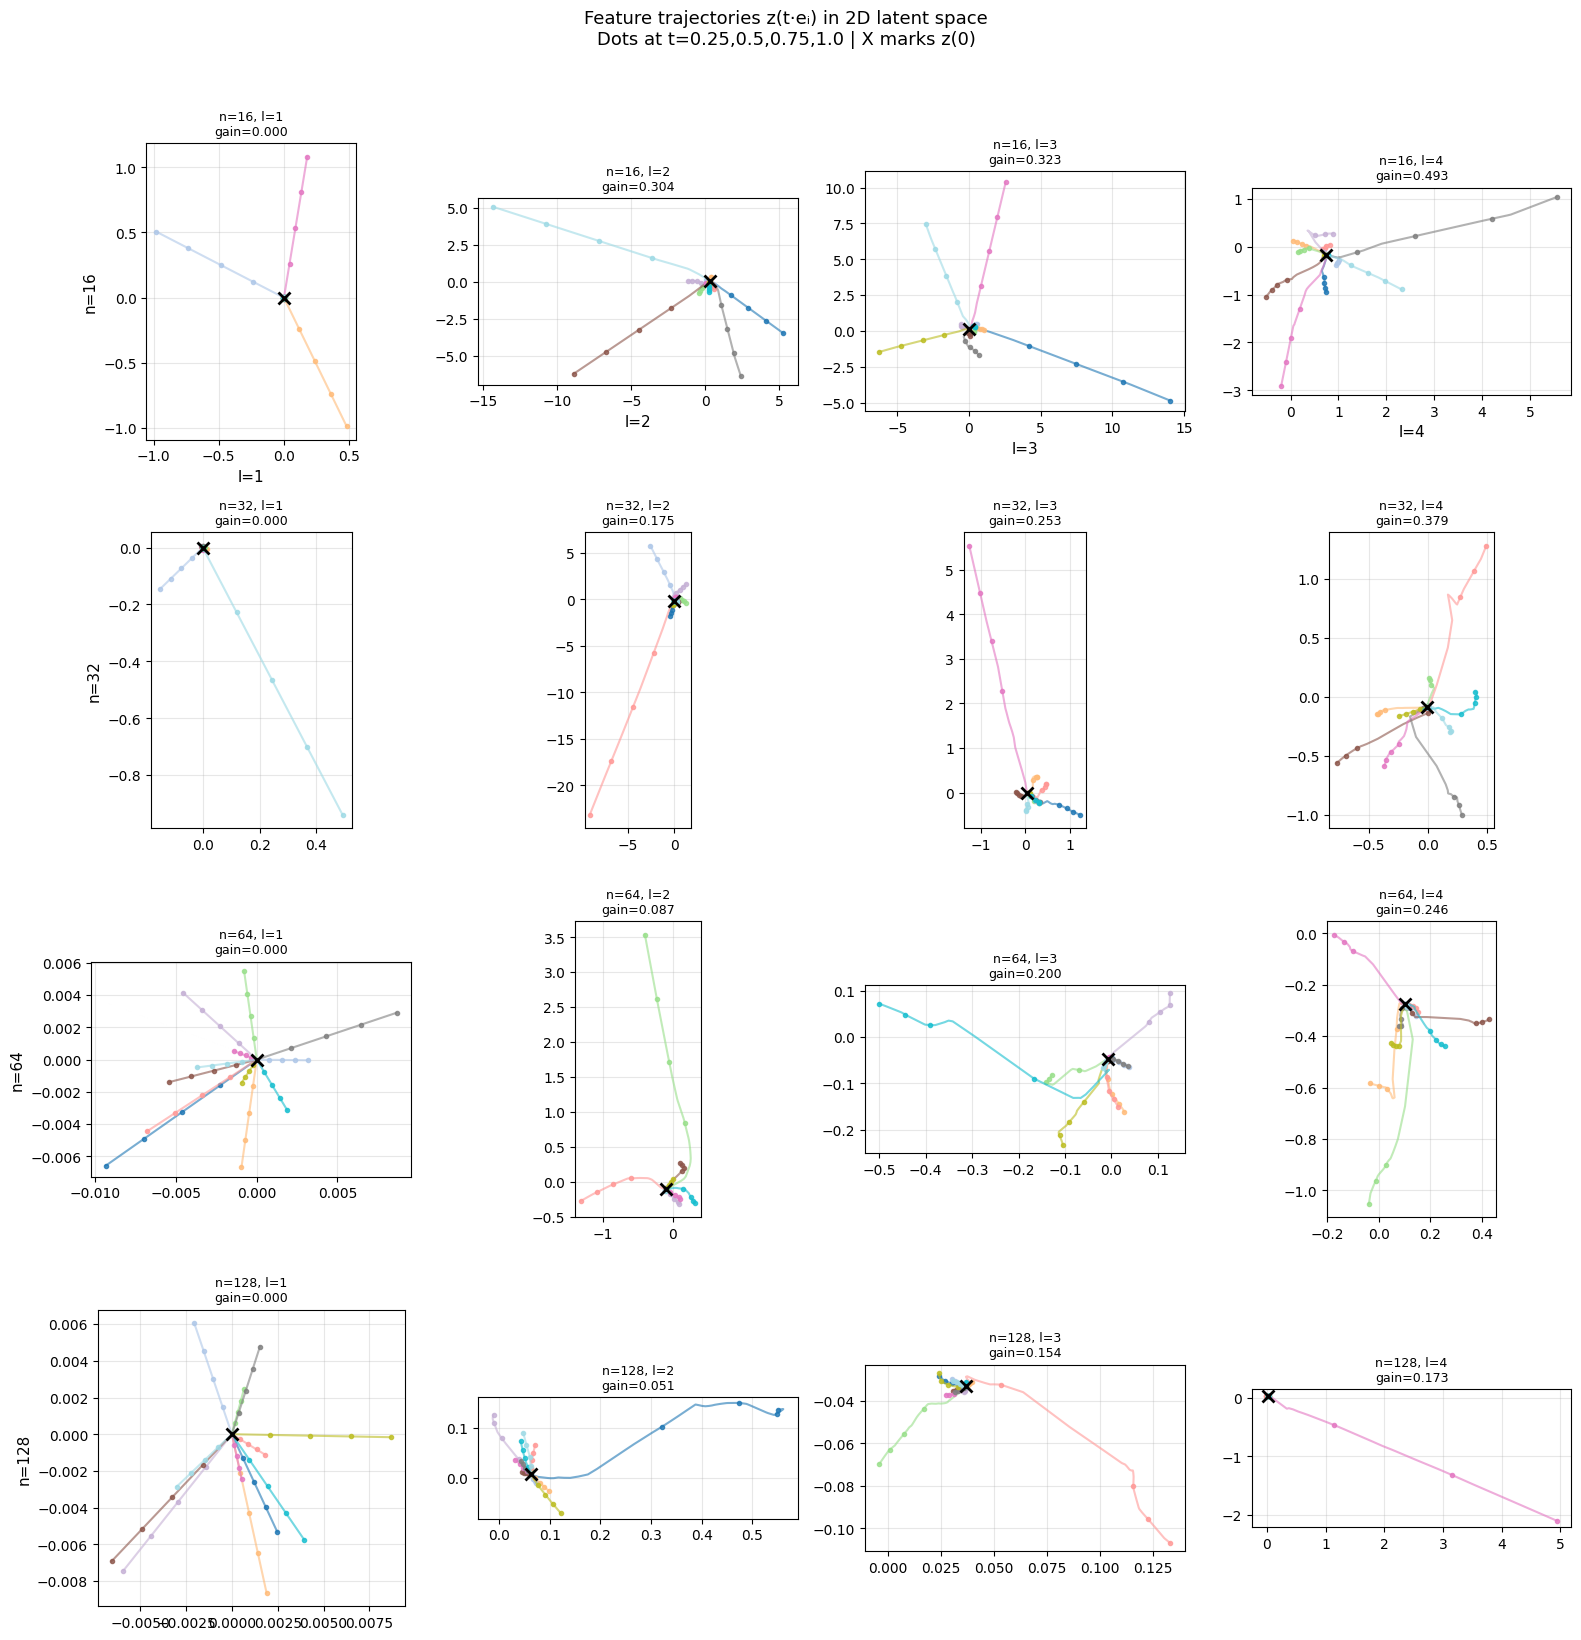

In [3]:
def plot_trajectories(model, ax, n_features=None, n_points=100, t_max=1.0,
                      show_ticks=True, cmap='tab20'):
    """Plot feature trajectories z(t*e_i) in 2D latent space."""
    n = model.n
    if n_features is None:
        n_features = min(n, 16)
    
    colors = plt.cm.get_cmap(cmap)(np.linspace(0, 1, n_features))
    t_values = torch.linspace(0, t_max, n_points, device=device)
    tick_t = [0.25, 0.5, 0.75, 1.0]
    
    model.eval()
    with torch.no_grad():
        for i in range(n_features):
            traj_input = torch.zeros(n_points, n, device=device)
            traj_input[:, i] = t_values
            z = model.encode(traj_input).cpu().numpy()
            
            ax.plot(z[:, 0], z[:, 1], color=colors[i], alpha=0.6, linewidth=1.5)
            
            # Tick marks at specific magnitudes
            if show_ticks:
                for t in tick_t:
                    idx = int(t / t_max * (n_points - 1))
                    ax.plot(z[idx, 0], z[idx, 1], 'o', color=colors[i],
                           markersize=3, alpha=0.8)
        
        # Mark z(0)
        z0 = model.encode(torch.zeros(1, n, device=device)).cpu().numpy()
        ax.plot(z0[0, 0], z0[0, 1], 'kx', markersize=8, markeredgewidth=2)
    
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)


# Plot grid: rows=n, cols=l
fig, axes = plt.subplots(len(n_values), len(l_values), figsize=(16, 16))

for i, n in enumerate(n_values):
    for j, l in enumerate(l_values):
        ax = axes[i, j]
        model = models[(n, l)]
        info = model_info[(n, l)]
        
        plot_trajectories(model, ax, n_features=min(n, 12))
        
        ax.set_title(f'n={n}, l={l}\ngain={info["gain"]:.3f}', fontsize=9)
        if j == 0:
            ax.set_ylabel(f'n={n}', fontsize=11)
        if i == 0:
            ax.set_xlabel(f'l={l}', fontsize=11)

plt.suptitle('Feature trajectories z(t·eᵢ) in 2D latent space\n'
             'Dots at t=0.25,0.5,0.75,1.0 | X marks z(0)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig_trajectories_m2.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Decoder Heatmaps

For each point in z-space, run through decoder to see what it reconstructs.
Shows which feature dominates reconstruction at each z location.

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_16076/2967703657.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(np.linspace(0, 1, n_features))


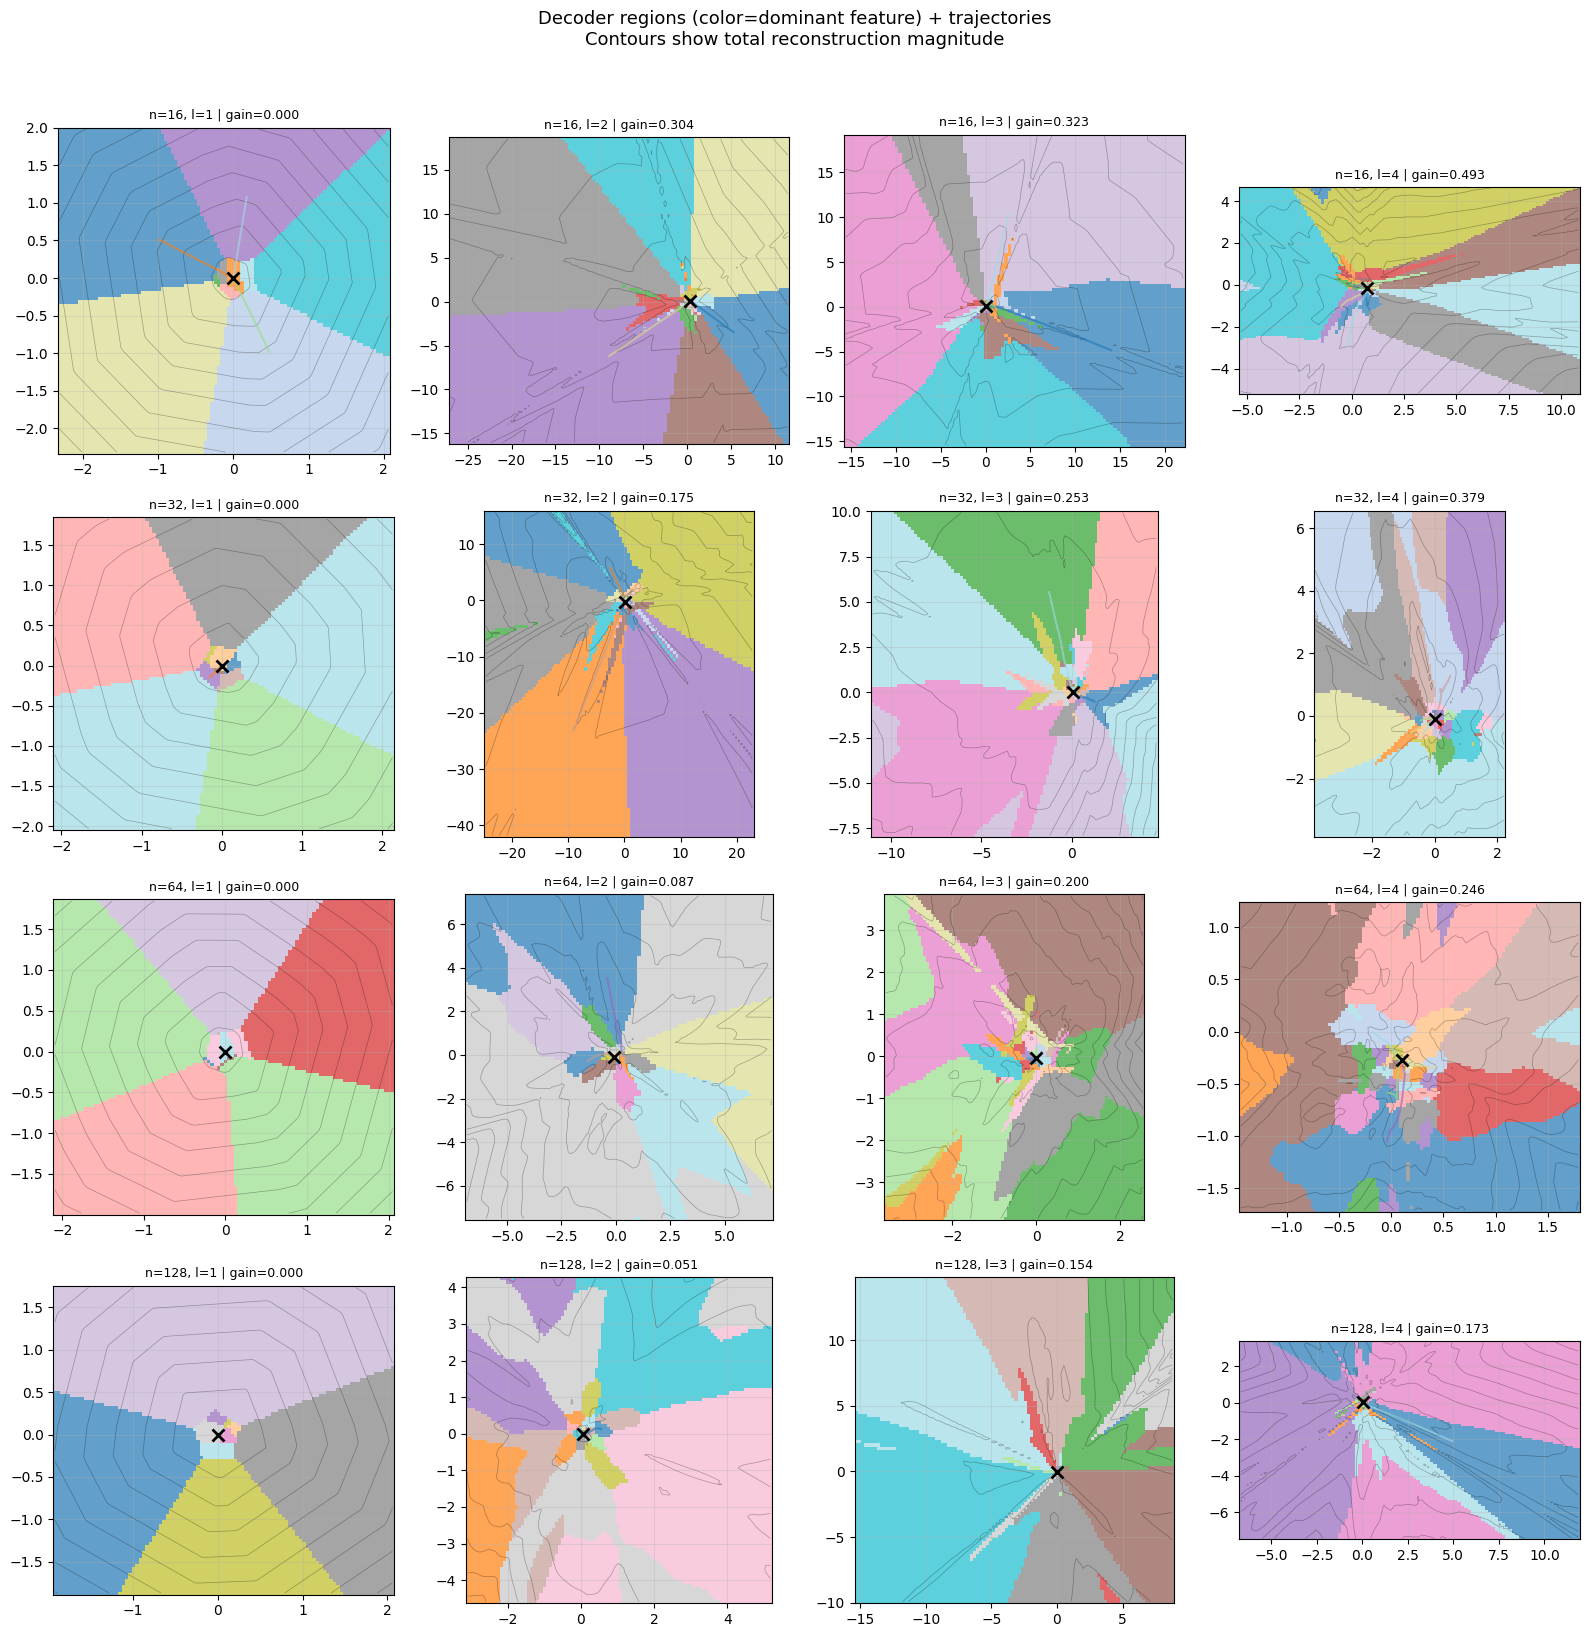

In [4]:
def plot_decoder_heatmap(model, ax, grid_size=100, z_range=None):
    """Color each z-point by which feature the decoder reconstructs most strongly."""
    model.eval()
    
    # Auto-determine z range from data
    if z_range is None:
        with torch.no_grad():
            x_test = generate_sparse_data(2000, model.n, S)
            z_test = model.encode(x_test)
            z_min = z_test.min(dim=0).values.cpu().numpy()
            z_max = z_test.max(dim=0).values.cpu().numpy()
            margin = 0.2 * (z_max - z_min)
            z_range = (z_min - margin, z_max + margin)
    
    z1 = np.linspace(z_range[0][0], z_range[1][0], grid_size)
    z2 = np.linspace(z_range[0][1], z_range[1][1], grid_size)
    Z1, Z2 = np.meshgrid(z1, z2)
    z_grid = torch.tensor(np.stack([Z1.ravel(), Z2.ravel()], axis=1),
                          dtype=torch.float32, device=device)
    
    with torch.no_grad():
        x_recon = model.decode(z_grid).cpu().numpy()
    
    # Dominant feature at each point
    dominant = x_recon.argmax(axis=1).reshape(grid_size, grid_size)
    
    # Total reconstruction magnitude
    magnitude = x_recon.sum(axis=1).reshape(grid_size, grid_size)
    
    ax.pcolormesh(Z1, Z2, dominant, cmap='tab20', alpha=0.7, shading='auto')
    ax.contour(Z1, Z2, magnitude, levels=8, colors='black', alpha=0.3, linewidths=0.5)
    ax.set_aspect('equal')


# Plot grid
fig, axes = plt.subplots(len(n_values), len(l_values), figsize=(16, 16))

for i, n in enumerate(n_values):
    for j, l in enumerate(l_values):
        ax = axes[i, j]
        model = models[(n, l)]
        info = model_info[(n, l)]
        
        plot_decoder_heatmap(model, ax)
        
        # Overlay trajectories
        plot_trajectories(model, ax, n_features=min(n, 8), show_ticks=False)
        
        ax.set_title(f'n={n}, l={l} | gain={info["gain"]:.3f}', fontsize=9)

plt.suptitle('Decoder regions (color=dominant feature) + trajectories\n'
             'Contours show total reconstruction magnitude', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig_decoder_m2.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Latent Scatter

Where does actual data land in z-space? Color by reconstruction error.

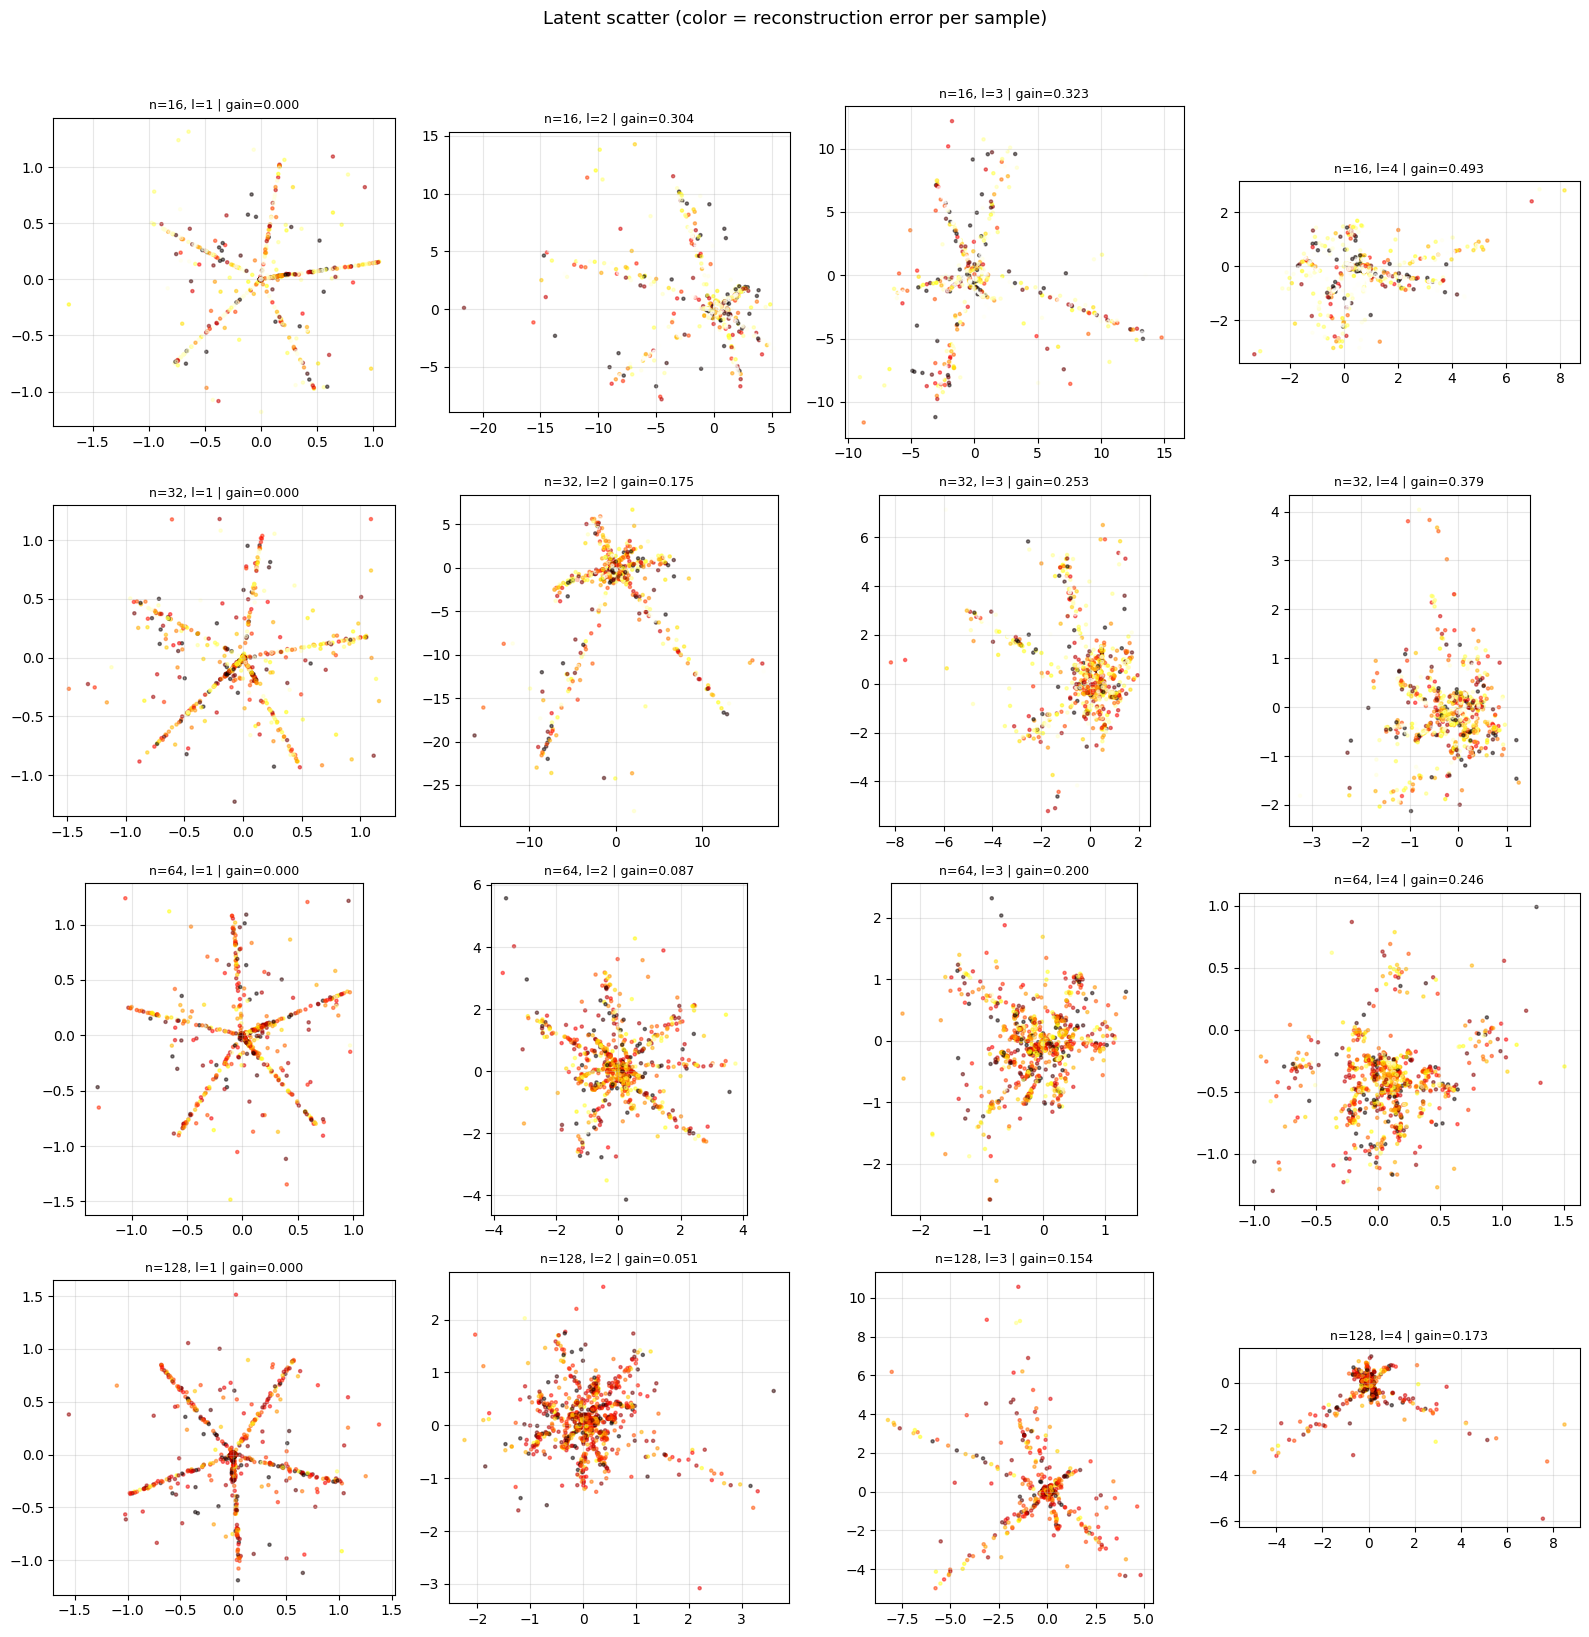

In [5]:
fig, axes = plt.subplots(len(n_values), len(l_values), figsize=(16, 16))

for i, n in enumerate(n_values):
    for j, l in enumerate(l_values):
        ax = axes[i, j]
        model = models[(n, l)]
        info = model_info[(n, l)]
        
        model.eval()
        with torch.no_grad():
            x = generate_sparse_data(1000, n, S)
            z = model.encode(x).cpu().numpy()
            x_recon, _ = model(x)
            errors = ((x_recon - x) ** 2).mean(dim=1).cpu().numpy()
        
        sc = ax.scatter(z[:, 0], z[:, 1], c=errors, cmap='hot_r',
                       s=5, alpha=0.5, vmin=0, vmax=np.percentile(errors, 95))
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_title(f'n={n}, l={l} | gain={info["gain"]:.3f}', fontsize=9)

plt.suptitle('Latent scatter (color = reconstruction error per sample)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig_scatter_m2.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Superposition Test

Test additivity: is z(eᵢ + eⱼ) ≈ z(eᵢ) + z(eⱼ) - z(0)?

For linear encoders this holds exactly. Violations indicate nonlinear interaction.

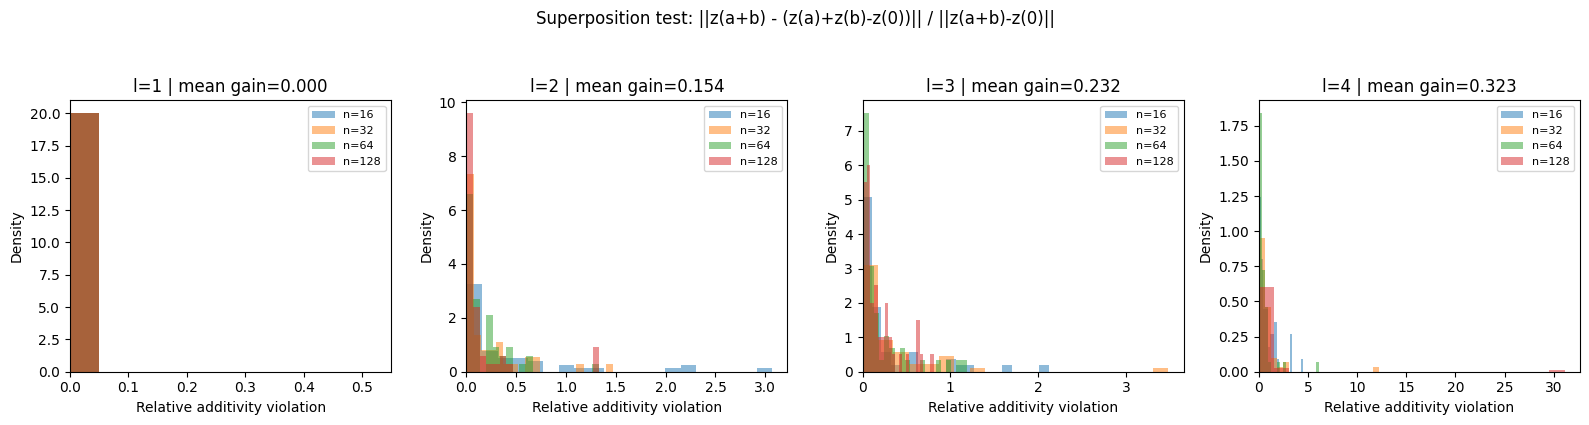

In [6]:
def compute_additivity_violation(model, n_pairs=20):
    """Measure how much z(a+b) deviates from z(a) + z(b) - z(0)."""
    model.eval()
    n = model.n
    violations = []
    
    with torch.no_grad():
        z0 = model.encode(torch.zeros(1, n, device=device))
        
        for _ in range(n_pairs):
            i, j = np.random.choice(n, 2, replace=False)
            
            ei = torch.zeros(1, n, device=device)
            ej = torch.zeros(1, n, device=device)
            eij = torch.zeros(1, n, device=device)
            ei[0, i] = 1.0
            ej[0, j] = 1.0
            eij[0, i] = 1.0
            eij[0, j] = 1.0
            
            z_i = model.encode(ei)
            z_j = model.encode(ej)
            z_ij = model.encode(eij)
            
            z_predicted = z_i + z_j - z0
            violation = torch.norm(z_ij - z_predicted).item()
            scale = torch.norm(z_ij - z0).item()
            
            if scale > 1e-6:
                violations.append(violation / scale)
    
    return np.array(violations)


# Plot superposition violations across the grid
fig, axes = plt.subplots(1, len(l_values), figsize=(16, 4))

for j, l in enumerate(l_values):
    ax = axes[j]
    for n in n_values:
        model = models[(n, l)]
        violations = compute_additivity_violation(model, n_pairs=50)
        ax.hist(violations, bins=20, alpha=0.5, label=f'n={n}', density=True)
    ax.set_xlabel('Relative additivity violation')
    ax.set_ylabel('Density')
    ax.set_title(f'l={l} | mean gain={np.mean([model_info[(n,l)]["gain"] for n in n_values]):.3f}')
    ax.legend(fontsize=8)
    ax.set_xlim(0, None)

plt.suptitle('Superposition test: ||z(a+b) - (z(a)+z(b)-z(0))|| / ||z(a+b)-z(0)||', y=1.05)
plt.tight_layout()
plt.savefig('fig_superposition_m2.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Arc/Chord Ratios

Scalar summary of trajectory curvature across the grid.

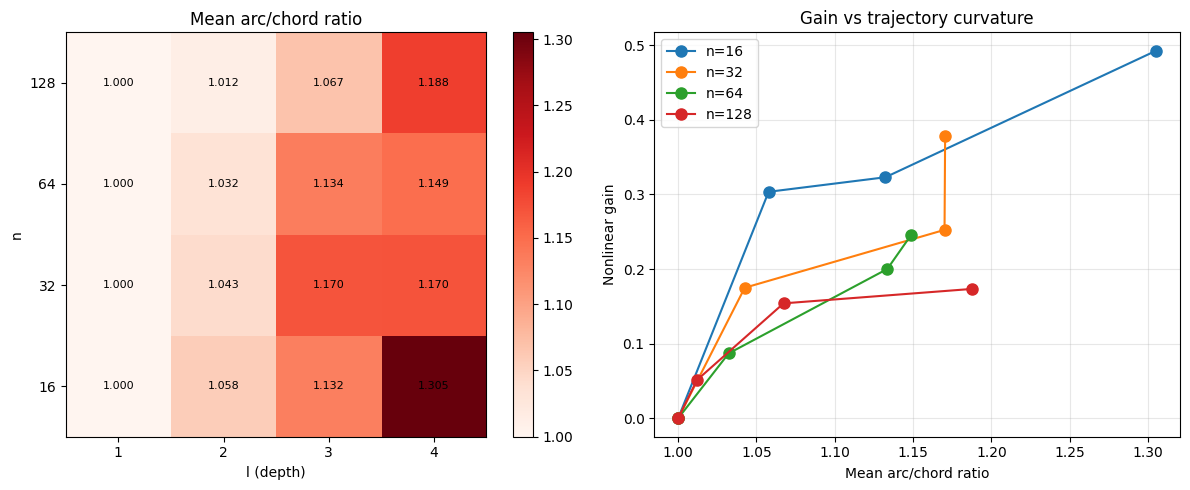

In [7]:
from metrics import compute_arc_chord_ratio

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap of mean arc/chord
ac_grid = np.zeros((len(n_values), len(l_values)))
for i, n in enumerate(n_values):
    for j, l in enumerate(l_values):
        ac = compute_arc_chord_ratio(models[(n, l)])
        ac_grid[i, j] = ac['arc_chord_mean']

ax = axes[0]
im = ax.imshow(ac_grid, aspect='auto', cmap='Reds', origin='lower', vmin=1.0)
ax.set_xticks(range(len(l_values)))
ax.set_xticklabels(l_values)
ax.set_yticks(range(len(n_values)))
ax.set_yticklabels(n_values)
ax.set_xlabel('l (depth)')
ax.set_ylabel('n')
ax.set_title('Mean arc/chord ratio')
for i in range(len(n_values)):
    for j in range(len(l_values)):
        ax.text(j, i, f'{ac_grid[i,j]:.3f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)

# Gain vs arc/chord scatter
ax = axes[1]
for n in n_values:
    gains = [model_info[(n, l)]['gain'] for l in l_values]
    acs = [compute_arc_chord_ratio(models[(n, l)])['arc_chord_mean'] for l in l_values]
    ax.plot(acs, gains, 'o-', label=f'n={n}', markersize=8)
ax.set_xlabel('Mean arc/chord ratio')
ax.set_ylabel('Nonlinear gain')
ax.set_title('Gain vs trajectory curvature')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_arc_chord_m2.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [8]:
import pandas as pd

rows = []
for (n, l), info in model_info.items():
    ac = compute_arc_chord_ratio(models[(n, l)])
    violations = compute_additivity_violation(models[(n, l)], n_pairs=50)
    rows.append({
        'n': n, 'l': l,
        'nonlinear_gain': info['gain'],
        'mse_full': info['mse_full'],
        'arc_chord_mean': ac['arc_chord_mean'],
        'arc_chord_max': ac['arc_chord_max'],
        'additivity_violation_mean': violations.mean(),
    })

df_m2 = pd.DataFrame(rows).sort_values(['n', 'l'])
print(df_m2.to_string(index=False))

  n  l  nonlinear_gain  mse_full  arc_chord_mean  arc_chord_max  additivity_violation_mean
 16  1    0.000000e+00  0.022784        1.000000       1.000000                   0.000000
 16  2    3.036065e-01  0.014234        1.057772       1.299653                   0.409660
 16  3    3.231071e-01  0.014052        1.132322       1.770105                   0.304765
 16  4    4.926966e-01  0.012412        1.305181       2.667461                   0.698079
 32  1    0.000000e+00  0.025905        1.000000       1.000000                   0.000000
 32  2    1.750207e-01  0.022339        1.042509       1.222665                   0.246184
 32  3    2.525849e-01  0.020658        1.170093       2.303625                   0.361071
 32  4    3.788984e-01  0.018270        1.170474       1.526246                   0.538393
 64  1    0.000000e+00  0.028580        1.000000       1.000000                   0.000000
 64  2    8.704487e-02  0.027292        1.032260       1.335445                   0.178269